In [1]:

import sys
original_sys_path = sys.path.copy()
sys.path.append('../')
from utils import *


In [2]:

ql = 20
ol = 25
system = fluxonium_oscillator_system(
    EJ = 2.33,
    EC = 0.69,
    EL = 0.12,
    Er = 7.16518677,
    g_strength = 0.18,
    qubit_level = ql,
    osc_level = ol,
    # kappa = 0.001,
    products_to_keep=[[ql, ol] for ql in [1,2] for ol in range(15) ] \
                    + [[ql, ol] for ql in [0,3] for ol in range(25) ],
    computaional_states = '1,2',
    w_d = 7.16475
    )


In [3]:
def get_dressed_state_overlaps(hamiltonian, product_index):
    """
    For a given product state index, finds the dressed states with decreasing overlap and the corresponding overlaps.
    
    Parameters:
    - H_with_interaction_no_drive: Hamiltonian in the product basis of a coupled system.
    - product_index: Index of the product state for which overlaps are calculated.
    
    Returns:
    - dressed_indices: Indices of the dressed states ordered by decreasing overlap with the product state.
    - overlaps: Overlaps of the dressed states with the product state.
    """
    # Compute eigenstates of the Hamiltonian
    evals, evecs = hamiltonian.eigenstates()
    overlap_matrix = scqubits.utils.spectrum_utils.convert_evecs_to_ndarray(evecs)

    # Extract overlaps for the specified product state with all dressed states
    overlaps_with_product_state = np.abs(overlap_matrix[:, product_index])
    
    # Sort the dressed states by decreasing overlap with the product state
    sorted_indices = np.argsort(overlaps_with_product_state)[::-1]  # Indices of dressed states sorted by overlap
    sorted_overlaps = overlaps_with_product_state[sorted_indices]  # Sorted overlaps
    
    return list(sorted_indices), list(sorted_overlaps)

In [6]:
top_dressed_states, overlaps = get_dressed_state_overlaps(hamiltonian = system.hilbertspace.hamiltonian(),
                           product_index = 1 * system.osc.truncated_dim + 0)
top_dressed_states[:2], overlaps[:2]

([1, 7], [0.9999544378628553, 0.005845889959102739])

In [7]:
top_dressed_states, overlaps = get_dressed_state_overlaps(hamiltonian = system.hilbertspace.hamiltonian(),
                           product_index = 1 * system.osc.truncated_dim + 1)
top_dressed_states[:2], overlaps[:2]

([12, 6], [0.9996475228535758, 0.018417139876932748])

In [8]:
top_dressed_states, overlaps = get_dressed_state_overlaps(hamiltonian = system.hilbertspace.hamiltonian(),
                           product_index = 1 * system.osc.truncated_dim + 2)
top_dressed_states[:2], overlaps[:2]

([31, 22], [0.9993407795476351, 0.025916261526726297])

In [9]:
top_dressed_states, overlaps = get_dressed_state_overlaps(hamiltonian = system.hilbertspace.hamiltonian(),
                           product_index = 1 * system.osc.truncated_dim + 3)
top_dressed_states[:2], overlaps[:2]

([51, 42], [0.9990342067631491, 0.031587671513207405])

In [10]:
top_dressed_states, overlaps = get_dressed_state_overlaps(hamiltonian = system.hilbertspace.hamiltonian(),
                           product_index = 1 * system.osc.truncated_dim + 4)
top_dressed_states[:2], overlaps[:2]

([71, 62], [0.9987278032269628, 0.03630338481449337])

In [3]:
tot_time =800
tlist = np.linspace(0, tot_time, tot_time)

results = system.run_mesolve_on_driving_osc(
    initial_states = [system.truncate_function(qutip.basis(system.hilbertspace.dimension, system.product_to_dressed[(i, 0)])) for i in range(4)],
    tlist = tlist,
    osc_decay = False,
    amp = 0.0015,
)



 *********99%***********] Elapsed 41.22s / Remaining 00:00:00:00:00[          0%           ] Elapsed 0.00s / Remaining 00:00:00:00[          0%           ] Elapsed 0.00s / Remaining 00:00:00:00[          0%           ] Elapsed 0.00s / Remaining 00:00:00:00[          0%           ] Elapsed 0.02s / Remaining 00:00:00:00 [          0%           ] Elapsed 0.03s / Remaining 00:00:00:00[          0%           ] Elapsed 0.03s / Remaining 00:00:00:00  [          0%           ] Elapsed 0.06s / Remaining 00:00:00:00[          0%           ] Elapsed 0.06s / Remaining 00:00:00:00[          0%           ] Elapsed 0.07s / Remaining 00:00:00:00[          0%           ] Elapsed 0.09s / Remaining 00:00:00:00[          0%           ] Elapsed 0.10s / Remaining 00:00:00:00[          0%           ] Elapsed 0.11s / Remaining 00:00:00:00[          0%           ] Elapsed 0.11s / Remaining 00:00:00:00[          0%           ] Elapsed 0.13s / Remaining 00:00:00:00  [          0%           ] Elapsed 0.14s / Rema

Processing states with pad_back_custom:   0%|          | 0/800 [00:00<?, ?it/s]

 [*********95%********** ] Elapsed 41.26s / Remaining 00:00:00:02[*********94%********** ] Elapsed 41.27s / Remaining 00:00:00:02[*********99%***********] Elapsed 41.28s / Remaining 00:00:00:00[*********99%***********] Elapsed 41.33s / Remaining 00:00:00:00[*********95%********** ] Elapsed 41.33s / Remaining 00:00:00:02

Processing states with pad_back_custom:  19%|█▉        | 152/800 [00:00<00:00, 1515.46it/s]

 [*********94%********** ] Elapsed 41.36s / Remaining 00:00:00:02[*********95%********** ] Elapsed 41.39s / Remaining 00:00:00:02[*********99%***********] Elapsed 41.40s / Remaining 00:00:00:00[*********94%********** ] Elapsed 41.41s / Remaining 00:00:00:02

...

Processing states with pad_back_custom:   0%|          | 0/800 [00:00<?, ?it/s]

 [********100%***********] Elapsed 43.73s / Remaining 00:00:00:00[********100%***********] Elapsed 43.79s / Remaining 00:00:00:00

Processing states with pad_back_custom:  26%|██▋       | 212/800 [00:00<00:00, 2115.31it/s]

 [********100%***********] Elapsed 43.86s / Remaining 00:00:00:00Total run time:  43.86s


Processing states with pad_back_custom: 100%|██████████| 800/800 [00:00<00:00, 2072.32it/s]


In [4]:

# import pickle
# with open('../pickles/sesolve_three_outcome_drive_final.pkl', 'wb') as file:
#     pickle.dump(results, file)


In [5]:

# with open('../pickles/sesolve_three_outcome_drive_final.pkl', 'rb') as file:
#     results = pickle.load(file)

2024-02-16 18:21:43.940470: E external/xla/xla/stream_executor/cuda/cuda_driver.cc:268] failed call to cuInit: UNKNOWN ERROR (100)


 /home/jiakai/.local/lib/python3.10/site-packages/matplotlib/cbook/__init__.py: 1340

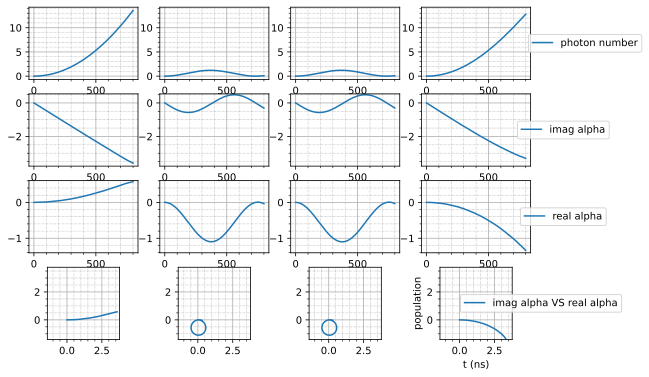

In [6]:
plot_population(results,
                system.qbt.truncated_dim,
                system.osc.truncated_dim,
                system.product_to_dressed,
                system.a,
                system.w_d,
                tlist,
                fourier=True,
                fix_ylim=True,
                plot_only_pn_alpha= True)

 /home/jiakai/.local/lib/python3.10/site-packages/matplotlib/cbook/__init__.py: 1340

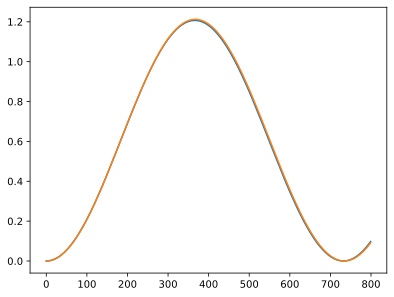

In [7]:
def get_pn_expect(result,a):
    pn_op = jnp.array((a.dag()*a).full())

    # Vectorize the function compute_expectation over the kets
    vectorized_compute_expectation = vmap(compute_expectation, in_axes=(0, None))
    vectorized_compute_expectation = jit(vectorized_compute_expectation)

    if hasattr(result, 'y'):
        states = jnp.array(result.y)  # assuming y contains JAX arrays or density matrices
    elif hasattr(result, 'states'):
        states = jnp.stack([jnp.array(q.full()) for q in result.states])  # assuming states contains QObj or density matrices

    pns_expect = vectorized_compute_expectation(states, pn_op)
    return pns_expect

pn_exp_one = get_pn_expect(results[1],system.a)
pn_exp_two = get_pn_expect(results[2],system.a)

plt.plot(pn_exp_one)
plt.plot(pn_exp_two)

In [8]:
def find_valley_index(values):
    # First, find the index of the peak
    peak_index = 0
    for i in range(1, len(values)):
        if values[i] < values[i - 1]:
            peak_index = i - 1
            break

    # Next, find the minimum value after the peak
    valley_index = peak_index + values[peak_index:].index(min(values[peak_index:]))

    return valley_index

index_of_valley_1 = find_valley_index(list(pn_exp_one))
index_of_valley_2 = find_valley_index(list(pn_exp_two))
index_of_valley_1, index_of_valley_2

(732, 734)

 /home/jiakai/.local/lib/python3.10/site-packages/matplotlib/cbook/__init__.py: 1340

(0.0, 0.001)

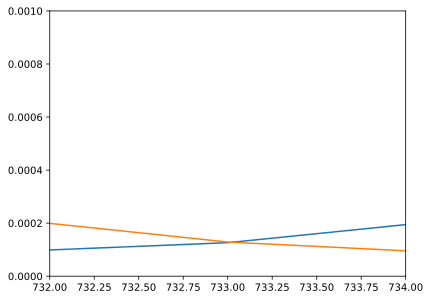

In [10]:
plt.plot(pn_exp_one)
plt.plot(pn_exp_two)
plt.xlim(index_of_valley_1,index_of_valley_2)
plt.ylim(0,0.001)

nonhermicity: Frobenius norm of the difference between rho and rho dag 0.0
trace: 0.999999999989385
nonhermicity: Frobenius norm of the difference between rho and rho dag 0.0
trace: 0.9999999999980732
nonhermicity: Frobenius norm of the difference between rho and rho dag 0.0
trace: 0.9999999999981126
nonhermicity: Frobenius norm of the difference between rho and rho dag 0.0
trace: 0.9999999999890866


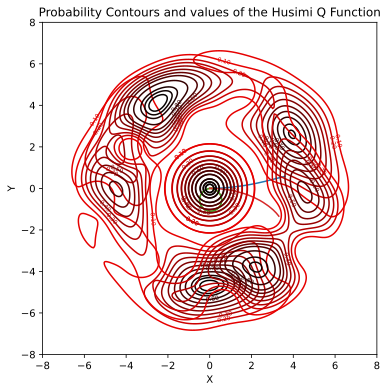

In [12]:
plt.figure(figsize=(6,6))

first_dominant_freq = find_dominant_frequency(results[0].expect[0],tlist)
 
def plot_husimi_probability_contours(dressed_state,product_to_dressed,qubit_level,osc_level):
    if dressed_state.dims[-1][0] == 1:
        dressed_state = qutip.ket2dm(dressed_state)
    dressed_dm_data = dressed_state.full()
    rho_product = np.zeros((qubit_level * osc_level, qubit_level * osc_level), dtype=complex)
    for (ql, ol), dressed_level in product_to_dressed.items():
        index1 = ql * osc_level + ol
        # Loop again to populate the density matrix
        for (ql2, ol2), dressed_level2 in product_to_dressed.items():
            index2 = ql2 * osc_level + ol2
            # TODO  the order of product_state and product_state2 doesn't make sense to me, but it produces the right result. :(
            element = dressed_dm_data[dressed_level, dressed_level2]
            rho_product[index1, index2] += element
    rho_product = qutip.Qobj(rho_product, dims=[[qubit_level, osc_level], [qubit_level, osc_level]])
    rho_coherent = rho_product.ptrace(1)

    # print(f"nonhermicity: abs(rho_coherent - rho_coherent.dag()).data.max() {abs(rho_coherent - rho_coherent.dag()).data.max()}")
    print(f"nonhermicity: Frobenius norm of the difference between rho and rho dag {np.linalg.norm((rho_coherent - rho_coherent.dag()).full(), 'fro')}")
    rho_coherent = 0.5 * (rho_coherent + rho_coherent.dag())

    print(f"trace: {rho_coherent.tr()}")
    rho_coherent = rho_coherent / rho_coherent.tr()


    xvec = np.linspace(-20,20,500)

    Q_coherent = qutip.qfunc(rho_coherent, xvec, xvec)

    q_values = Q_coherent
    sorted_q = np.sort(q_values.ravel())
    cumulative_sum = np.cumsum(sorted_q)
    total_sum = cumulative_sum[-1]
    X, Y = np.meshgrid(xvec, xvec)
    for prob in [0.9,0.8,0.7,0.6,0.5,0.4,0.3,0.2,0.1,0.05,0.02]:
        level_value = sorted_q[np.argmax(cumulative_sum >= total_sum * (1 - prob))]
        contour = plt.contour(X, Y, q_values, levels=[level_value], colors=[(prob, 0, 0, 1)])
        fmt = {level_value:f'{1 - prob:.2f}'}
        plt.clabel(contour, inline=False, fontsize=6, fmt=fmt)

    # Q_coherent[Q_coherent < sorted_q[np.argmax(cumulative_sum >= total_sum * (1 - 0.98))]] = None
    # plt.contourf(xvec, xvec, Q_coherent, 100)

alpha = results[0].expect[-2]*np.exp(-1j * 2 * np.pi * first_dominant_freq * tlist)
line, = plt.plot(-alpha.imag,alpha.real)

alpha = results[1].expect[-2]*np.exp(-1j * 2 * np.pi * first_dominant_freq * tlist)
line, = plt.plot(-alpha.imag,alpha.real)

alpha = results[2].expect[-2]*np.exp(-1j * 2 * np.pi * first_dominant_freq * tlist)
line, = plt.plot(-alpha.imag,alpha.real)

alpha = results[3].expect[-2]*np.exp(-1j * 2 * np.pi * first_dominant_freq * tlist)
line, = plt.plot(-alpha.imag,alpha.real)

t_idx = 733

plot_husimi_probability_contours(dressed_state=results[0].states[t_idx],
                                 product_to_dressed=system.product_to_dressed,
                                 qubit_level = system.qubit_level,
                                 osc_level = system.osc_level)
plot_husimi_probability_contours(dressed_state=results[1].states[t_idx],
                                 product_to_dressed=system.product_to_dressed,
                                 qubit_level = system.qubit_level,
                                 osc_level = system.osc_level)

plot_husimi_probability_contours(dressed_state=results[2].states[t_idx],
                                 product_to_dressed=system.product_to_dressed,
                                 qubit_level = system.qubit_level,
                                 osc_level = system.osc_level)

plot_husimi_probability_contours(dressed_state=results[3].states[t_idx],
                                 product_to_dressed=system.product_to_dressed,
                                 qubit_level = system.qubit_level,
                                 osc_level = system.osc_level)

plt.title("Probability Contours and values of the Husimi Q Function")
plt.xlabel("X")
plt.ylabel("Y")
plt.xlim(-8,8)
plt.ylim(-8,8)

plt.show()

In [16]:
interactive_heatmap(results[1], system.product_to_dressed, system.qbt.truncated_dim, system.osc.truncated_dim)

interactive(children=(IntSlider(value=0, continuous_update=False, description='Time Index:', max=799), Output(…

 /tmp/ipykernel_1126/1106547948.py: 39

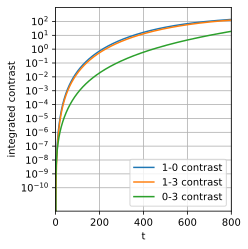

In [13]:
plt.figure(figsize=(3+3/8,3+3/8))
kappa_val = 1e-3

alpha1 = results[1].expect[-2]*np.exp(-1j * 2 * np.pi * first_dominant_freq * tlist)
alpha0 = results[0].expect[-2]*np.exp(-1j * 2 * np.pi * first_dominant_freq * tlist)
squared_diff = np.square(abs(alpha0-alpha1))
integrals = [0.0]
for i in range(1,len(tlist)):
    integrals.append(integrals[i-1]+
                        (tlist[i]-tlist[i-1])*np.sqrt(kappa_val)*squared_diff[i]
                        )
    
plt.plot(tlist,integrals,label='1-0 contrast')

alpha3 = results[3].expect[-2]*np.exp(-1j * 2 * np.pi * first_dominant_freq * tlist)
squared_diff = np.square(abs(alpha3-alpha1))
integrals = [0.0]
for i in range(1,len(tlist)):
    integrals.append(integrals[i-1]+
                        (tlist[i]-tlist[i-1])*np.sqrt(kappa_val)*squared_diff[i]
                        )
    
plt.plot(tlist,integrals,label='1-3 contrast')


squared_diff = np.square(abs(alpha3-alpha0))
integrals = [0.0]
for i in range(1,len(tlist)):
    integrals.append(integrals[i-1]+
                        (tlist[i]-tlist[i-1])*np.sqrt(kappa_val)*squared_diff[i]
                        )
    
plt.plot(tlist,integrals,label='0-3 contrast')



plt.legend(loc='lower right')
plt.yscale('log')
plt.ylim(0,1e3)
plt.yticks([1e-10,1e-9,1e-8,1e-7,1e-6,1e-5,1e-4,1e-3,1e-2,1e-1,1,1e1,1e2])
plt.xlim(0,tot_time)
plt.grid()
plt.tight_layout()
plt.xlabel('t')
plt.ylabel('integrated contrast')
# plt.savefig("fig06_integral.pdf", format='pdf', bbox_inches='tight')
plt.show()

